## Data Preparation

### Introduction
------------------------------------------------

In this phase, I prepare the dataset so it can be used for machine learning. During the previous Data Understanding phase, I identified several issues that needed to be addressed before modeling.

Some of the main issues included:
- Inconsistent column names such as 2urvived and sibsp
- Several unnecessary columns beginning with “zero”
- A small number of missing values
- Skewed numeric variables, especially Fare
- Categorical variables that must be encoded before modeling
- Opportunities to create more meaningful features from existing variables

The goal of this phase is to produce a clean and model-ready dataset. To do this, I follow the standard steps defined in the CRISP-DM framework [5]:
1. Select relevant data
2. Clean and correct errors
3. Construct new features
4. Integrate data
5. Format the dataset for modeling
6. Split the dataset for training and evaluation

To keep the baseline model simple and easy to interpret, I temporarily exclude Embarked_Code from the final model features in this phase. I will test its usefulness later during the modeling stage.

#### Alignment with Data Understanding

The preparation steps in this phase are based on findings from the previous analysis.

From the Data Understanding phase, I observed that:
- Embarked contains a small number of missing values.
- Age and Fare do not have missing values in this dataset version.
- Fare is highly skewed.
- Family-related variables appear to influence survival patterns.
- Gender and passenger class show strong survival differences.

Based on these findings, I applied the following data preparation decisions:
1. I will create Fare_Bracket to make fare patterns easier to interpret.
2. I will create Family_Size and Is_Alone to represent family relationships.
3. I will keep gender and class variables because they showed strong survival signals.
4. I will clean the Embarked column but excluded it from baseline model inputs for now.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

from titanic_surv.dataset import load_data

# Load the Titanic dataset
data = load_data("titanic.csv")

# Display basic statistics for numeric columns

data.head()

2026-03-12 15:29:58.490 | INFO     | titanic_surv.config:<module>:11 - PROJ_ROOT path is: D:\py\Titanic\titanic_surv_pred_insights


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


### Research Questions
------------------------------------------------

The data preparation process is guided by several research questions that were identified during the exploration phase. [3], [4]

1. **RQ1** – Gender Effect:
Does passenger gender influence survival probability, and should gender be encoded as a predictive feature?
2. **RQ2** – Passenger Class
Does passenger class affect survival chances, and how should it be represented in the dataset?
3. **RQ3** – Age Influence
Does age influence survival outcomes, and would grouping ages improve interpretability?
4. **RQ4** – Fare and Socioeconomic Status
Does ticket fare reflect socioeconomic status and did it affect survival probability?
5. **RQ5** – Family Context
Does traveling alone versus with family influence survival outcomes?

These questions help guide how the dataset is cleaned and transformed.

### 1. Select Relevant Data
------------------------------------------------

The first step in data preparation is to select only the variables that are relevant to the project goal.

The raw dataset contains several columns that are not useful for survival prediction. Some columns begin with “zero” and do not provide meaningful information.

To keep the analysis focused and reduce noise in the model, I select the following key variables:
 - PassengerId
 - Age
 - Fare
 - Sex
 - SibSp
 - Parch
 - Pclass
 - Embarked
 - Survived

These variables represent passenger identity, demographics, family relationships, travel class, and survival outcome.

Selecting only the relevant columns makes the dataset easier to work with and helps prevent unnecessary complexity during modeling.

In [2]:
# Select relevant columns for analysis
selected_columns = [
    "Passengerid",
    "Age",
    "Fare",
    "Sex",
    "sibsp",
    "Parch",
    "Pclass",
    "Embarked",
    "2urvived"
]

# Create a working copy of the dataset
data_selected = data[selected_columns].copy()

# Check selected columns
data_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   2urvived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


### 2. Clean and Correct Errors
------------------------------------------------

The next step is to clean the dataset so that it is consistent and reliable.

This process includes:
 - Standardizing column names
 - Fixing spelling issues
 - Checking for incorrect or invalid values
 - Handling missing values
 - Converting variables to the correct data types
 - Performing a final quality check

For missing value handling, I use *median imputation* for numeric variables and *mode imputation* for categorical variables. Median values are often preferred because they are less affected by extreme values or outliers [1].

For this dataset, only the Embarked column contains missing values.

##### Cleaning Decisions and Trade-offs

To keep the project simple and explainable, I made several practical choices.

First, I used *median* and *mode* imputation as a reliable and easy-to-explain method. Even though Age and Fare do not currently have missing values, I keep the imputation rules in the pipeline in case future data contains missing values.

Second, I used simple rule-based checks to validate the dataset. For example:
- Age must fall within a realistic range.
- Fare values cannot be negative.

These checks are easier to reproduce than complex anomaly-detection techniques.

Finally, I cleaned the Embarked variable but excluded its encoded version from the baseline feature set. This keeps the initial model simpler while still allowing the variable to be tested later.

#### Step 1: Standardizing column names

In [3]:
# Standardize column names: remove spaces and ensure consistency
data_clean = data_selected.copy()
data_clean.columns = data_clean.columns.str.strip()

#### Step 2: Fixing spelling issues

In [4]:
# Rename incorrect column names to standard Titanic naming
data_clean = data_clean.rename(columns={
    "Passengerid": "PassengerId",
    "2urvived": "Survived",
    "sibsp": "SibSp"
})

# Verify column names
data_clean.columns

Index(['PassengerId', 'Age', 'Fare', 'Sex', 'SibSp', 'Parch', 'Pclass',
       'Embarked', 'Survived'],
      dtype='object')

#### Step 3: Checking for incorrect or invalid values

In [5]:
check_df = data_clean.copy()

# --- SEX checks ---
sex_raw = check_df["Sex"].astype(str).str.strip().str.lower()
sex_missing_like = check_df["Sex"].isna() | sex_raw.isin(["", "nan", "na", "none", "unknown", "?"])
sex_invalid = ~sex_raw.isin(["male", "female", "0", "1"]) & ~sex_missing_like

# --- AGE checks ---
age_num = pd.to_numeric(check_df["Age"], errors="coerce")
age_missing_like = check_df["Age"].isna() | age_num.isna()   # catches non-numeric too
age_invalid = (age_num < 0) | (age_num > 100)               # choose range for your project

# --- FARE checks ---
fare_num = pd.to_numeric(check_df["Fare"], errors="coerce")
fare_missing_like = check_df["Fare"].isna() | fare_num.isna() # catches non-numeric too
fare_invalid = fare_num < 0                                   # fare cannot be negative

# Summary table
quality_summary = pd.DataFrame({
    "Missing-like values": [
        int(sex_missing_like.sum()),
        int(age_missing_like.sum()),
        int(fare_missing_like.sum())
    ],
    "Invalid values": [
        int(sex_invalid.sum()),
        int(age_invalid.sum()),
        int(fare_invalid.sum())
    ]
}, index=["Sex", "Age", "Fare"])

print("Quality check for Sex, Age, Fare:")
print(quality_summary)

# Optional: show bad rows for manual review
bad_rows = check_df[sex_missing_like | sex_invalid | age_missing_like | age_invalid | fare_missing_like | fare_invalid]
print(f"\nRows with issues found: {len(bad_rows)}")
bad_rows.head(10)

Quality check for Sex, Age, Fare:
      Missing-like values  Invalid values
Sex                     0               0
Age                     0               0
Fare                    0               0

Rows with issues found: 0


,PassengerId,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived


#### Step 4: Handling missing values

Before filling missing values, I first check how many missing values exist in each column. This helps me justify the imputation strategy.

In [6]:
# Check missing values before handling them
missing_before = data_clean.isnull().sum().sort_values(ascending=False)
missing_before = missing_before[missing_before > 0]

print("Missing values before imputation:")
if missing_before.empty:
    print("No missing values found.")
else:
    print(missing_before)

# Optional: quick percentage view
missing_before_pct = (data_clean.isnull().mean() * 100).round(2)
missing_before_pct = missing_before_pct[missing_before_pct > 0]

if not missing_before_pct.empty:
    print("\nMissing percentage (%):")
    print(missing_before_pct)

Missing values before imputation:
Embarked    2
dtype: int64

Missing percentage (%):
Embarked    0.15
dtype: float64


Then I handle null values using median (numeric) and mode (categorical)

In [7]:
# Fill missing values for categorical columns
# Normalize text first so mode/imputation is consistent.
data_clean["Sex"] = data_clean["Sex"].astype(str).str.strip().str.lower()
data_clean["Sex"] = data_clean["Sex"].replace({"nan": np.nan, "": np.nan})
data_clean["Sex"] = data_clean["Sex"].fillna(data_clean["Sex"].mode()[0])

data_clean["Embarked"] = data_clean["Embarked"].astype(str).str.strip().str.upper()
data_clean["Embarked"] = data_clean["Embarked"].replace({"NAN": np.nan, "": np.nan})
data_clean["Embarked"] = data_clean["Embarked"].fillna(data_clean["Embarked"].mode()[0])

# Fill missing values for Age and Fare with median values
data_clean["Age"] = data_clean["Age"].fillna(data_clean["Age"].median())
data_clean["Fare"] = data_clean["Fare"].fillna(data_clean["Fare"].median())
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   object 
 4   SibSp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1309 non-null   object 
 8   Survived     1309 non-null   int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 92.2+ KB


#### Step 5: Converting variables to the correct data types

In [8]:
# Ensure correct data types
data_clean["Survived"] = data_clean["Survived"].astype(int)
data_clean["Pclass"] = data_clean["Pclass"].astype(int)
data_clean["SibSp"] = data_clean["SibSp"].astype(int)
data_clean["Parch"] = data_clean["Parch"].astype(int)
data_clean["Fare"] = data_clean["Fare"].astype(float)

# Check current data types
data_clean.dtypes

PassengerId      int64
Age            float64
Fare           float64
Sex             object
SibSp            int64
Parch            int64
Pclass           int64
Embarked        object
Survived         int64
dtype: object

#### Step 6: Performing a final quality check

In [9]:
# Final clean-data check
# Keep Embarked as clean text at this stage; encode later in Format Data.
print("Embarked unique values:", sorted(data_clean["Embarked"].dropna().unique()))

# Summary after cleaning
data_clean.info()

Embarked unique values: ['0.0', '1.0', '2.0']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   object 
 4   SibSp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1309 non-null   object 
 8   Survived     1309 non-null   int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 92.2+ KB


### 3. Construct New Features
------------------------------------------------

After cleaning the dataset, I create several new features that help capture meaningful patterns in the data.

Feature engineering is widely used in machine learning to transform raw data into more informative variables [8].

Based on the previous analysis, I construct the following features:
 - Family_Size – total number of family members traveling together
 - Is_Alone – indicates whether the passenger traveled alone
 - Fare_Bracket – groups fares into interpretable categories
 - Pclass_Label – readable passenger class labels
 - Age_Group – categorizes passengers into life-stage groups

These features make survival patterns easier to interpret and can improve model performance.

Research on the Titanic disaster suggests that survival depended on factors such as social class, age, and group context [3], [4]. Creating these features helps capture those relationships.

#### Decision Trade-offs (Construct Data)

Feature construction involves some trade-offs.

Using grouped features such as Age_Group and Fare_Bracket improves interpretability but may reduce some detailed numeric information.

For example, grouping fares into categories helps highlight economic differences between passengers, but small variations in ticket price may be lost.

Despite this limitation, grouped features are useful for explaining patterns in the dataset and communicating insights clearly.

#### Step 1: Construct "Family_Size" Feature

In [10]:
# Family Size = siblings/spouses + parents/children + passenger
data_clean["Family_Size"] = data_clean["SibSp"] + data_clean["Parch"] + 1

# Preview result
data_clean[["SibSp", "Parch", "Family_Size"]].head()


,SibSp,Parch,Family_Size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


#### Step 2: Construct "Is Alone" Feature

In [11]:
# Create a binary feature: 1 if passenger is alone, else 0
data_clean["Is_Alone"] = (data_clean["Family_Size"] == 1).astype(int)

data_clean[["Family_Size", "Is_Alone"]].head()

,Family_Size,Is_Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


#### Step 3: Construct "Fare Bracket" Feature

In [12]:
# Create fare bands using quartiles
data_clean["Fare_Bracket"] = pd.qcut(
    data_clean["Fare"],
    q=4,
    labels=["Low Fare", "Medium Fare", "High Fare", "Very High Fare"]
)

# Check distribution
data_clean["Fare_Bracket"].value_counts()

Fare_Bracket
Low Fare          337
High Fare         328
Very High Fare    323
Medium Fare       321
Name: count, dtype: int64

#### Step 4: Construct "Passenger Class Labels" Feature 

In [13]:
# Map passenger class to readable labels
data_clean["Pclass_Label"] = data_clean["Pclass"].map({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})

data_clean[["Pclass", "Pclass_Label"]].head()

,Pclass,Pclass_Label
0,3,Third Class
1,1,First Class
2,3,Third Class
3,1,First Class
4,3,Third Class


#### Step 5: Construct "Age Group" Feature 

In [14]:
# Create Age Groups
age_bins = [0, 12, 18, 35, 60, 80]
age_group = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

data_clean["Age_Group"] = pd.cut(
    data_clean["Age"],
    bins=age_bins,
    labels=age_group,
    include_lowest=True
)

# Check distribution
data_clean["Age_Group"].value_counts()

Age_Group
Young Adult    794
Adult          289
Teen            99
Child           94
Senior          33
Name: count, dtype: int64

#### Step 6: Final Check of Constructed Features

In [15]:
# Verify new columns
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   PassengerId   1309 non-null   int64   
 1   Age           1309 non-null   float64 
 2   Fare          1309 non-null   float64 
 3   Sex           1309 non-null   object  
 4   SibSp         1309 non-null   int64   
 5   Parch         1309 non-null   int64   
 6   Pclass        1309 non-null   int64   
 7   Embarked      1309 non-null   object  
 8   Survived      1309 non-null   int64   
 9   Family_Size   1309 non-null   int64   
 10  Is_Alone      1309 non-null   int64   
 11  Fare_Bracket  1309 non-null   category
 12  Pclass_Label  1309 non-null   object  
 13  Age_Group     1309 non-null   category
dtypes: category(2), float64(2), int64(7), object(3)
memory usage: 125.8+ KB


### 4. Integrate Data
------------------------------------------------

Data integration normally involves combining multiple datasets from different sources.

In this project, the Titanic dataset already contains all the variables required for the analysis.

After reviewing the dataset, I found that:
 - Passenger demographics are already available.
 - Family relationship variables are present.
 - Ticket fare and passenger class are included.

Since the dataset already contains all relevant information, no additional external data sources are required.

Instead of integrating new data, I improved the dataset by creating new features such as Family_Size, Is_Alone, Age_Group, and Fare_Bracket.


#### Confirm dataset shape after preparation

In [16]:
data_clean.shape

(1309, 14)

#### Preview final dataset columns

In [17]:
data_clean.columns.tolist()

['PassengerId',
 'Age',
 'Fare',
 'Sex',
 'SibSp',
 'Parch',
 'Pclass',
 'Embarked',
 'Survived',
 'Family_Size',
 'Is_Alone',
 'Fare_Bracket',
 'Pclass_Label',
 'Age_Group']

#### Check if PassengerId is Unique

In [18]:
# Check for duplicate PassengerId after preparation
if data_clean["PassengerId"].is_unique:
    print("No duplicate PassengerId found.")
else:
    print("Duplicate PassengerId detected. Please investigate.")

No duplicate PassengerId found.


### 5. Format Data
------------------------------------------------

Before training machine learning models, the dataset must be converted into a format that algorithms can process.

Machine learning models cannot work directly with text labels. Therefore, categorical variables must be encoded as numeric values.

The formatting process includes:
 - Ensuring correct data types
 - Encoding categorical variables
 - Confirming the target variable
 - Verifying the final dataset structure

For example:
 - Sex is converted into Sex_Code (0 = male, 1 = female).
 - Pclass is converted into Pclass_Code.
 - Age and fare groups remain categorical but structured for analysis.

The target variable Survived is also confirmed to be a binary variable with values 0 and 1.

#### Step 1: Copy dataset to avoid modifying original

In [19]:
formatted_data_clean = data_clean.copy()
formatted_data_clean.head()

,PassengerId,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived,Family_Size,Is_Alone,Fare_Bracket,Pclass_Label,Age_Group
0,1,22.0,7.2500,0,1,0,3,2.0,0,2,0,Low Fare,Third Class,Young Adult
1,2,38.0,71.2833,1,1,0,1,0.0,1,2,0,Very High Fare,First Class,Adult
2,3,26.0,7.9250,1,0,0,3,2.0,1,1,1,Medium Fare,Third Class,Young Adult
3,4,35.0,53.1000,1,1,0,1,2.0,1,2,0,Very High Fare,First Class,Young Adult
4,5,35.0,8.0500,0,0,0,3,2.0,0,1,1,Medium Fare,Third Class,Young Adult


#### Step 2: Correct Data Types
- Ensure numeric columns are of type `int` or `float`.
- Ensure categorical columns are `category` or encoded properly.

In [20]:
numeric_cols = ["Age", "SibSp", "Parch", "Fare", "Family_Size"]
for col in numeric_cols:
    formatted_data_clean[col] = pd.to_numeric(formatted_data_clean[col], errors='coerce')

categorical_cols = ["Survived", "Pclass", "Sex", "Embarked", "Is_Alone", "Age_Group", "Fare_Bracket"]
for col in categorical_cols:
    formatted_data_clean[col] = formatted_data_clean[col].astype("category")

categorical_cols

['Survived',
 'Pclass',
 'Sex',
 'Embarked',
 'Is_Alone',
 'Age_Group',
 'Fare_Bracket']

#### Step 3: Encode Categorical Variables
- Replace an actual category for label - Sex (male"0"/female"1")
- Convert text labels (like "Sex" or "Pclass_Label") to numeric codes if needed.

In [21]:
# Format Sex column
formatted_data_clean["Sex"] = formatted_data_clean["Sex"].astype(str).str.strip().str.lower()
formatted_data_clean["Sex"] = formatted_data_clean["Sex"].replace({"0": "male", "1": "female"})  # map existing 0/1 to text
formatted_data_clean["Sex"] = formatted_data_clean["Sex"].where(
     formatted_data_clean["Sex"].isin(["male", "female"]), "male"
)

# Generate numeric Sex_Code: 0 for male, 1 for female
formatted_data_clean["Sex_Code"] = formatted_data_clean["Sex"].map({"male": 0, "female": 1}).astype(int)

# Ensure Pclass is numeric and create code
formatted_data_clean["Pclass"] = pd.to_numeric(formatted_data_clean["Pclass"], errors="coerce")
pclass_mode = formatted_data_clean["Pclass"].mode()[0]
formatted_data_clean["Pclass"] = formatted_data_clean["Pclass"].fillna(pclass_mode)
formatted_data_clean["Pclass_Code"] = formatted_data_clean["Pclass"].astype(int)

# Keep Embarked cleaned for reporting, but do not include Embarked_Code in final model features
formatted_data_clean["Embarked"] = formatted_data_clean["Embarked"].astype(str).str.strip().str.upper()
formatted_data_clean["Embarked"] = formatted_data_clean["Embarked"].replace({"NAN": np.nan, "": np.nan})
embarked_mode = formatted_data_clean["Embarked"].mode()[0]
formatted_data_clean["Embarked"] = formatted_data_clean["Embarked"].fillna(embarked_mode)

formatted_data_clean.head()

,PassengerId,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived,Family_Size,Is_Alone,Fare_Bracket,Pclass_Label,Age_Group,Sex_Code,Pclass_Code
0,1,22.0,7.2500,male,1,0,3,2.0,0,2,0,Low Fare,Third Class,Young Adult,0,3
1,2,38.0,71.2833,female,1,0,1,0.0,1,2,0,Very High Fare,First Class,Adult,1,1
2,3,26.0,7.9250,female,0,0,3,2.0,1,1,1,Medium Fare,Third Class,Young Adult,1,3
3,4,35.0,53.1000,female,1,0,1,2.0,1,2,0,Very High Fare,First Class,Young Adult,1,1
4,5,35.0,8.0500,male,0,0,3,2.0,0,1,1,Medium Fare,Third Class,Young Adult,0,3


In [22]:
# Evidence check for Embarked relevance in this prepared dataset
embarked_counts = formatted_data_clean["Embarked"].value_counts(dropna=False)
embarked_share = (embarked_counts / len(formatted_data_clean)).round(4)

print("Embarked value counts:")
print(embarked_counts)
print("\nEmbarked value shares:")
print(embarked_share)

dominant_share = float(embarked_share.max())
print(f"\nLargest single-category share: {dominant_share:.2%}")

# Rule used for this notebook: if one category dominates too strongly, drop encoded Embarked from model features
if dominant_share >= 0.85:
    print("Decision support: Embarked is highly concentrated; excluding Embarked_Code is justified.")
else:
    print("Decision support: Embarked has moderate variation; reassess exclusion during modeling.")

Embarked value counts:
Embarked
2.0    916
0.0    270
1.0    123
Name: count, dtype: int64

Embarked value shares:
Embarked
2.0    0.6998
0.0    0.2063
1.0    0.0940
Name: count, dtype: float64

Largest single-category share: 69.98%
Decision support: Embarked has moderate variation; reassess exclusion during modeling.


#### Step 4: Interpretation: Embarked Signal Evidence

This summary helps me decide whether `Embarked_Code` should be part of baseline model features.

In this run, `Embarked` still shows some variation, so I will keep it excluded for the baseline model but re-test it later during modeling to confirm whether it helps.

#### Step 5: Ensure Target Variable is Correct

In [23]:
formatted_data_clean["Survived"] = formatted_data_clean["Survived"].astype("int64")

#### Step 6: Check final dataset info

In [24]:
# Quick look at a few rows to confirm encoding
formatted_data_clean.head()

,PassengerId,Age,Fare,Sex,SibSp,Parch,Pclass,Embarked,Survived,Family_Size,Is_Alone,Fare_Bracket,Pclass_Label,Age_Group,Sex_Code,Pclass_Code
0,1,22.0,7.2500,male,1,0,3,2.0,0,2,0,Low Fare,Third Class,Young Adult,0,3
1,2,38.0,71.2833,female,1,0,1,0.0,1,2,0,Very High Fare,First Class,Adult,1,1
2,3,26.0,7.9250,female,0,0,3,2.0,1,1,1,Medium Fare,Third Class,Young Adult,1,3
3,4,35.0,53.1000,female,1,0,1,2.0,1,2,0,Very High Fare,First Class,Young Adult,1,1
4,5,35.0,8.0500,male,0,0,3,2.0,0,1,1,Medium Fare,Third Class,Young Adult,0,3


#### Step 7: Visualize Final dataset

In this step, I visualize the prepared dataset to see how survival rates vary across key features. I create charts showing survival by Pclass_Code, Sex_Code, Age_Group, Fare_Bracket, and Is_Alone. These charts help confirm whether the patterns found earlier are still visible after data understanding.

**Insight:**
 - The chart shows that female passengers (1) have a much higher survival rate than male passengers (0). This suggests that gender is a strong predictor and should remain in the final feature set.
 - The passenger class chart shows that first-class passengers survived more often than third-class passengers. This indicates that passenger class is an important feature for the model.
 - The age group chart shows that children have higher survival rates, while adults and seniors have lower rates. Grouping ages makes this pattern easier to understand.
 - The fare bracket chart suggests that passengers who paid higher fares generally had better survival chances.
 - The Is_Alone chart shows that passengers traveling with family tend to survive slightly more often than those traveling alone.

Overall, these visualizations confirm that the prepared features still show meaningful survival patterns and help answer research questions RQ1–RQ5.

Survival rate by Pclass_Code:
 Pclass_Code
1    0.421
2    0.314
3    0.168
Name: Survived, dtype: float64

Survival rate by Sex_Code (0=male, 1=female):
 Sex_Code
0    0.129
1    0.500
Name: Survived, dtype: float64

Survival rate by Age_Group:
 Age_Group
Child          0.426
Teen           0.303
Young Adult    0.238
Adult          0.270
Senior         0.152
Name: Survived, dtype: float64

Survival rate by Fare_Bracket:
 Fare_Bracket
Low Fare          0.131
Medium Fare       0.212
High Fare         0.308
Very High Fare    0.399
Name: Survived, dtype: float64

Survival rate by Is_Alone:
 Is_Alone
0    0.345
1    0.206
Name: Survived, dtype: float64


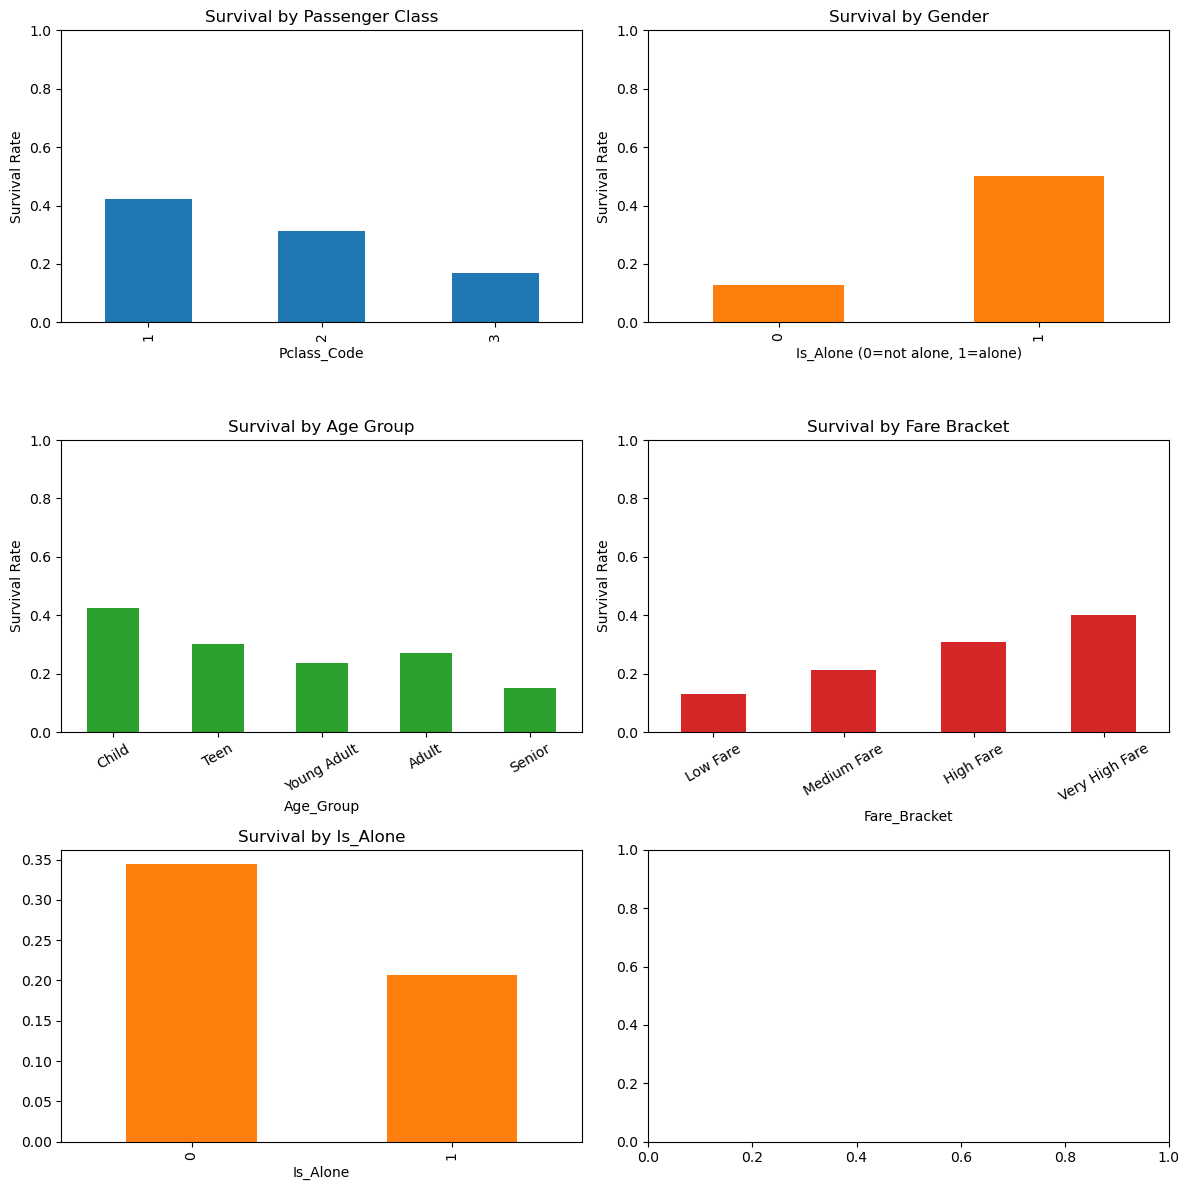

In [42]:
import matplotlib.pyplot as plt

signal_df = formatted_data_clean.copy()

# Survival rate tables
survival_by_class = signal_df.groupby("Pclass_Code", observed=False)["Survived"].mean().sort_index()
survival_by_gender = signal_df.groupby("Sex_Code", observed=False)["Survived"].mean().sort_index()
survival_by_age = signal_df.groupby("Age_Group", observed=False)["Survived"].mean()
survival_by_fare = signal_df.groupby("Fare_Bracket", observed=False)["Survived"].mean()
survival_by_is_alone = signal_df.groupby("Is_Alone", observed=False)["Survived"].mean()

print("Survival rate by Pclass_Code:\n", survival_by_class.round(3))
print("\nSurvival rate by Sex_Code (0=male, 1=female):\n", survival_by_gender.round(3))
print("\nSurvival rate by Age_Group:\n", survival_by_age.round(3))
print("\nSurvival rate by Fare_Bracket:\n", survival_by_fare.round(3))
print("\nSurvival rate by Is_Alone:\n", survival_by_is_alone.round(3))

# Ordered views for clearer interpretation
age_order = ["Child", "Teen", "Young Adult", "Adult", "Senior"]
fare_order = ["Low Fare", "Medium Fare", "High Fare", "Very High Fare"]
survival_by_age = survival_by_age.reindex(age_order)
survival_by_fare = survival_by_fare.reindex(fare_order)

# 2x2 visualization grid
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

survival_by_class.plot(kind="bar", ax=axes[0, 0], color="#1f77b4", title="Survival by Passenger Class")
axes[0, 0].set_xlabel("Pclass_Code")
axes[0, 0].set_ylabel("Survival Rate")
axes[0, 0].set_ylim(0, 1)

survival_by_gender.plot(kind="bar", ax=axes[0, 1], color="#ff7f0e", title="Survival by Gender")
axes[0, 1].set_xlabel("Sex_Code (0=male, 1=female)")
axes[0, 1].set_ylabel("Survival Rate")
axes[0, 1].set_ylim(0, 1)

survival_by_age.plot(kind="bar", ax=axes[1, 0], color="#2ca02c", title="Survival by Age Group")
axes[1, 0].set_xlabel("Age_Group")
axes[1, 0].set_ylabel("Survival Rate")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis="x", rotation=30)

survival_by_fare.plot(kind="bar", ax=axes[1, 1], color="#d62728", title="Survival by Fare Bracket")
axes[1, 1].set_xlabel("Fare_Bracket")
axes[1, 1].set_ylabel("Survival Rate")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=30)

survival_by_is_alone.plot(kind="bar", ax=axes[2, 0], color="#ff7f0e", title="Survival by Is_Alone")
axes[0, 1].set_xlabel("Is_Alone (0=not alone, 1=alone)")
axes[0, 1].set_ylabel("Survival Rate")
axes[0, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

<!-- ...existing code... -->
#### Step 8: Normalization Decision

Normalization is not applied in this baseline workflow.

Several features such as Sex_Code, Is_Alone, and Pclass_Code already have small numeric ranges. Scaling these variables would not meaningfully change the model results.

Tree-based models such as Decision Trees and Random Forests are also insensitive to feature scale because they rely on threshold splits rather than distance calculations [1].

For logistic regression, feature scaling can sometimes improve performance. However, in this project I already grouped Age and Fare into categorical features, which reduces the scale difference between variables.

If I later decide to use raw Age or Fare values, I may apply normalization in the modeling phase.

### 6. Split Dataset
------------------------------------------------

After completing data preparation, I split the dataset into training, validation, and test sets.

This step ensures that model evaluation is fair and unbiased.

The dataset is divided as follows:
 - Training Set (70%) – used to train the models
 - Validation Set (15%) – used for model tuning and comparison
 - Test Set (15%) – used for final evaluation

Stratified sampling is used so that each dataset maintains the same survival ratio as the original dataset. This approach is recommended for classification problems with imbalanced classes [3], [5].

The final dataset sizes are:
 - Training set: 916 passengers
 - Validation set: 196 passengers
 - Test set: 197 passengers

The processed datasets are saved for use in the modeling phase.

In [26]:
from sklearn.model_selection import train_test_split
from titanic_surv.dataset import save_processed_data

# Define model-ready features and target
model_features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Family_Size",
    "Sex_Code",
    "Pclass_Code"
]

model_data = formatted_data_clean[model_features + ["Survived"]].copy()
X = model_data.drop(columns=["Survived"])
y = model_data["Survived"]

#### Step 1: Split into training (70%) and temp (30% for validation + test)

In [27]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#### Step 2: Split temp into validation (15%) and test (15% of original)

In [28]:
# Now split temp (30%) into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Combine features and target back for saving
train_df = X_train.copy()
train_df["Survived"] = y_train

validate_df = X_val.copy()
validate_df["Survived"] = y_val

test_df = X_test.copy()
test_df["Survived"] = y_test

In [29]:
# Verify stratification quality across splits
def survival_rate(s):
    return round(float(s.mean()), 4)

rates = {
    "full": survival_rate(y),
    "train": survival_rate(y_train),
    "validate": survival_rate(y_val),
    "test": survival_rate(y_test),
}

print("Survival rates by split:", rates)

# Allow a small tolerance due to finite sample sizes
tol = 0.03
assert abs(rates["train"] - rates["full"]) <= tol
assert abs(rates["validate"] - rates["full"]) <= tol
assert abs(rates["test"] - rates["full"]) <= tol

print("Stratification ratio check passed.")

Survival rates by split: {'full': 0.2613, 'train': 0.2609, 'validate': 0.2602, 'test': 0.264}
Stratification ratio check passed.


#### Step 3: Save the processed dataset

In [30]:
# Save processed datasets
save_processed_data(train_df, filename="titanic_training.csv")
save_processed_data(validate_df, filename="titanic_validate.csv")
save_processed_data(test_df, filename="titanic_test.csv")

# Print dataset sizes
print(f"Training set size: {train_df.shape[0]} samples")
print(f"Validation set size: {validate_df.shape[0]} samples")
print(f"Test set size: {test_df.shape[0]} samples")

2026-03-12 15:30:01.509 | SUCCESS  | titanic_surv.dataset:save_processed_data:33 - Processed data saved to D:\py\Titanic\titanic_surv_pred_insights\data\processed\titanic_training.csv
2026-03-12 15:30:01.509 | SUCCESS  | titanic_surv.dataset:save_processed_data:33 - Processed data saved to D:\py\Titanic\titanic_surv_pred_insights\data\processed\titanic_validate.csv
2026-03-12 15:30:01.509 | SUCCESS  | titanic_surv.dataset:save_processed_data:33 - Processed data saved to D:\py\Titanic\titanic_surv_pred_insights\data\processed\titanic_test.csv
Training set size: 916 samples
Validation set size: 196 samples
Test set size: 197 samples


### 7. Pre-Modeling Validation Checklist
------------------------------------------------

Before moving to model development, I verify several conditions:
 - The target variable exists and is binary.
 - All model features are numeric.
 - Categorical variables are properly encoded.
 - The target variable is not included in the feature matrix.
 - No duplicate rows or overlapping records exist between datasets.
 - Training, validation, and test sets maintain the correct proportions.

These checks help ensure that the dataset is ready for machine learning and that no data leakage occurs.

#### Step 1: Confirm Target Variable Exists

In [31]:
assert "Survived" in formatted_data_clean.columns, "Target variable 'Survived' not found."

print("Target variable exists.")


Target variable exists.


#### Step 2: Confirm Target Is Binary (0 and 1 Only)

In [32]:
unique_values = sorted(formatted_data_clean["Survived"].unique())

print("Unique target values:", unique_values)

assert set(unique_values) == {0, 1}, "Target variable is not binary (0 and 1 only)."

print("Target variable is correctly binary.")

Unique target values: [np.int64(0), np.int64(1)]
Target variable is correctly binary.


#### Step 3: Confirm All Key Features Are Numeric

In [33]:
feature_df = X.copy()

# Check data types of model features
non_numeric_model_features = (
    feature_df
    .select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

assert len(non_numeric_model_features) == 0, (
    f"Non-numeric model features found: {non_numeric_model_features}"
)
print("All model features are numeric and model-ready.")

All model features are numeric and model-ready.


#### Step 4: Confirm Categorical Variables Are Encoded

If the previous step shows no non-numeric columns, then categorical encoding is confirmed.

In [34]:
print(feature_df.dtypes)

Age            float64
Fare           float64
SibSp            int64
Parch            int64
Family_Size      int64
Sex_Code         int64
Pclass_Code      int64
dtype: object


#### Step 5: Check for Data Leakage

Data leakage often happens when:
- Target-related information is included in features
- Post-event variables are used

In [35]:
# 1) Name-based leakage check
leakage_cols = [col for col in feature_df.columns if "surv" in col.lower()]
assert len(leakage_cols) == 0, f"Possible leakage columns by name: {leakage_cols}"

# 2) Identifier check
assert "PassengerId" not in feature_df.columns, "PassengerId should not be used as a modeling feature."

# 3) Constant-column check
constant_cols = [col for col in feature_df.columns if feature_df[col].nunique(dropna=False) <= 1]
if constant_cols:
    print(f"Warning: Constant or near-useless columns found: {constant_cols}")
    print("Recommendation: Drop these columns before final model training if they remain constant.")
else:
    print("No constant columns found.")

print("Leakage and feature sanity checks completed.")

No constant columns found.
Leakage and feature sanity checks completed.


#### Step 6: Ensure Target Is Not Included in Feature Matrix

In [36]:
assert "Survived" not in feature_df.columns, "Target variable included in feature set!"

print("Target variable not included in features.")


Target variable not included in features.


#### Step 7: Confirm Dataset Sizes (70 / 15 / 15)

In [37]:
total_rows = (
    len(train_df) + 
    len(validate_df) + 
    len(test_df)
)

original_rows = len(formatted_data_clean)

print("Original rows:", original_rows)
print("Total split rows:", total_rows)

assert total_rows == original_rows, "Split datasets do not sum to original dataset size."

print("Dataset split sizes are consistent.")


Original rows: 1309
Total split rows: 1309
Dataset split sizes are consistent.


#### Step 8: Confirm No Overlap Between Datasets

In [38]:
train_index = set(train_df.index)
validate_index = set(validate_df.index)
test_index = set(test_df.index)

assert train_index.isdisjoint(validate_index), "Overlap between train and validation!"
assert train_index.isdisjoint(test_index), "Overlap between train and test!"
assert validate_index.isdisjoint(test_index), "Overlap between validation and test!"

print("No overlap between train, validation, and test datasets.")


No overlap between train, validation, and test datasets.


### 8. Clear Intermediate Objects
------------------------------------------------

After saving the training, validation, and test datasets, I no longer need some of the intermediate variables that were used during preparation and splitting.

To reduce memory use in the notebook, I delete objects such as temporary feature tables and split helper variables. 

I keep only the final outputs that may still be useful later, such as the saved datasets and any final split tables needed for the next phase.

In [ ]:
import gc

# Delete intermediate objects no longer needed
del model_data, X, y, X_temp, y_temp, feature_df

# Optional: also delete earlier working tables if Phase 3 is complete
del data_selected, data_clean

gc.collect()

print("Intermediate objects deleted.")

### References
------------------------------------------------
[1] G. James, D. Witten, T. Hastie, and R. Tibshirani, *An Introduction to Statistical Learning: With Applications in R*, 2nd ed. New York, NY, USA: Springer, 2021.

[2] D. B. Rubin, *Multiple Imputation for Nonresponse in Surveys*. New York, NY, USA: John Wiley & Sons, 1987.

[3] B. S. Frey, D. A. Savage, and B. Torgler, "Behavior under extreme conditions: The Titanic disaster," *Journal of Economic Perspectives*, vol. 25, no. 1, pp. 209-222, 2011.

[4] D. Gleicher, "The Rescue of the Titanic Survivors," *Journal of Social History*, vol. 40, no. 1, pp. 157-178, 2006.

[5] P. Chapman et al., "CRISP-DM 1.0: Step-by-step data mining guide," 2000.

[6] Scikit-learn Developers, "train_test_split," *scikit-learn documentation*. [Online]. Available: https://scikit-learn.org/

[7] J. W. Tukey, *Exploratory Data Analysis*. Reading, MA, USA: Addison-Wesley, 1977.

[8] A. Zheng and A. Casari, *Feature Engineering for Machine Learning: Principles and Techniques for Data Scientists*. Sebastopol, CA, USA: O'Reilly Media, 2018.

[9] J. Han, M. Kamber, and J. Pei, *Data Mining: Concepts and Techniques*, 3rd ed. Waltham, MA, USA: Morgan Kaufmann, 2011.